In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
class VegetableDataset(Dataset):
    def __init__(self, root_dir, transform=None):
      
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.samples = []
        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            class_idx = self.class_to_idx[class_name]
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_path, img_name), class_idx))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, class_idx = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, class_idx


def get_transforms(train=True):
    """Create image transforms for training or evaluation"""
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])


In [ ]:

class VegetableClassifier:
    def __init__(self, num_classes=15, model_name="resnet50"):
       
        self.num_classes = num_classes
        self.model_name = model_name
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        
        # Create model
        self.model = self._create_model(model_name, num_classes)
        self.model = self.model.to(self.device)
        
        # Define class names
        self.class_names = [
            'bean', 'bitter_gourd', 'bottle_gourd', 'brinjal', 'broccoli', 
            'cabbage', 'capsicum', 'carrot', 'cauliflower', 'cucumber', 
            'papaya', 'potato', 'pumpkin', 'radish', 'tomato'
        ]
    
    def _create_model(self, model_name, num_classes):
        """Create the model with the specified architecture"""
        model = models.resnet50(weights='IMAGENET1K_V1')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    
    def train(self, train_dir, val_dir, batch_size=32, num_epochs=10, learning_rate=0.001):
        
        # Create datasets and data loaders
        train_dataset = VegetableDataset(train_dir, transform=get_transforms(train=True))
        val_dataset = VegetableDataset(val_dir, transform=get_transforms(train=False))
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # Print dataset information
        print(f"Training images: {len(train_dataset)}")
        print(f"Validation images: {len(val_dataset)}")
        print(f"Number of classes: {len(train_dataset.classes)}")
        self.class_names = train_dataset.classes
        
        # Define loss function and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        
        # Training loop
        best_val_acc = 0.0
        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")
            
            # Training phase
            self.model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0
            
            for inputs, labels in tqdm(train_loader, desc="Training"):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward + backward + optimize
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()
            
            epoch_train_loss = train_loss / len(train_loader.dataset)
            epoch_train_acc = train_correct / train_total
            
            # Validation phase
            self.model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for inputs, labels in tqdm(val_loader, desc="Validation"):
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    loss = criterion(outputs, labels)
                    
                    val_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
            
            epoch_val_loss = val_loss / len(val_loader.dataset)
            epoch_val_acc = val_correct / val_total
            
            print(f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
            print(f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")
            
            # Save best model
            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                torch.save(self.model.state_dict(), 'best_vegetable_model.pth')
                print("Saved best model!")
        
        # Load best model
        self.model.load_state_dict(torch.load('best_vegetable_model.pth'))
        print(f"Training complete! Best validation accuracy: {best_val_acc:.4f}")
    
    def evaluate(self, test_dir, batch_size=32):
       
        test_dataset = VegetableDataset(test_dir, transform=get_transforms(train=False))
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        print(f"Test dataset: {len(test_dataset)} images")
        
        self.model.eval()
        all_preds = []
        all_labels = []
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc="Evaluating"):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs, 1)
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = correct / total
        
        # Print results
        print(f"Test Accuracy: {accuracy:.4f}")
        
        # Calculate confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        
        # Plot confusion matrix
        self._plot_confusion_matrix(cm)
        
        return accuracy
    
    def _plot_confusion_matrix(self, cm):
        plt.figure(figsize=(12, 10))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        
        # Add class labels
        tick_marks = np.arange(len(self.class_names))
        plt.xticks(tick_marks, self.class_names, rotation=90)
        plt.yticks(tick_marks, self.class_names)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'),
                         horizontalalignment="center",
                         color="white" if cm[i, j] > thresh else "black")
        
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png')
        plt.show()
    
    def save_model(self, path='vegetable_classifier.pth'):
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")
    
    def load_model(self, path='vegetable_classifier.pth'):
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.eval()
        print(f"Model loaded from {path}")
    
    def predict(self, image_path):
        
        # Load and preprocess the image
        image = Image.open(image_path).convert('RGB')
        transform = get_transforms(train=False)
        image_tensor = transform(image).unsqueeze(0).to(self.device)
        
        # Make prediction
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(image_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]
            
            # Get the predicted class and probability
            predicted_class_idx = torch.argmax(probabilities).item()
            probability = probabilities[predicted_class_idx].item()
            
            # Get top 3 predictions
            top3_values, top3_indices = torch.topk(probabilities, 3)
            top3_predictions = [
                (self.class_names[idx.item()], val.item())
                for idx, val in zip(top3_indices, top3_values)
            ]
        
        return self.class_names[predicted_class_idx], probability, top3_predictions


def visualize_prediction(image_path, classifier):
  
    # Load image
    image = Image.open(image_path).convert('RGB')
    
    # Get prediction
    predicted_class, confidence, top_3 = classifier.predict(image_path)
    true_class = os.path.basename(os.path.dirname(image_path))
    
    # Display the image with predictions
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(f"True: {true_class} | Predicted: {predicted_class} ({confidence:.2%})")
    plt.axis('off')
    
    # Add top 3 predictions text
    y_pos = 0.15
    for veg, conf in top_3:
        plt.figtext(0.7, y_pos, f"{veg}: {conf:.2%}")
        y_pos += 0.05
    
    plt.tight_layout()
    plt.show()


In [ ]:
# Main function to run the classifier
def run_vegetable_classifier(data_dir='dataset', model_name='resnet50', batch_size=32, 
                           num_epochs=10, learning_rate=0.001, eval_mode=False):

    # Print system info
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    
    # Set paths
    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'validation')
    test_dir = os.path.join(data_dir, 'test')
    
    # Create classifier
    classifier = VegetableClassifier(num_classes=15, model_name=model_name)
    
    # Load or train model
    if eval_mode and os.path.exists('best_vegetable_model.pth'):
        classifier.load_model('best_vegetable_model.pth')
    else:
        # Train the model
        classifier.train(
            train_dir=train_dir,
            val_dir=val_dir,
            batch_size=batch_size,
            num_epochs=num_epochs,
            learning_rate=learning_rate
        )
    
    # Evaluate model
    if os.path.exists(test_dir):
        classifier.evaluate(test_dir, batch_size=batch_size)
    
    # Show example prediction
    try:
        # Find a sample image
        sample_class = os.listdir(test_dir)[0]
        sample_dir = os.path.join(test_dir, sample_class)
        sample_img = os.path.join(sample_dir, os.listdir(sample_dir)[0])
        visualize_prediction(sample_img, classifier)
    except:
        print("Couldn't find sample image for prediction demonstration")
    
    return classifier

PyTorch version: 2.6.0+cu124
CUDA available: True
Using device: cuda
Training images: 15000
Validation images: 3000
Number of classes: 15
Epoch 1/5


Validation: 100%|██████████| 188/188 [00:30<00:00,  6.12it/s]


Train Loss: 0.9520, Train Acc: 0.7015
Val Loss: 0.3454, Val Acc: 0.9037
Saved best model!
Epoch 2/5


Validation: 100%|██████████| 188/188 [00:24<00:00,  7.71it/s]


Train Loss: 0.4158, Train Acc: 0.8722
Val Loss: 0.1577, Val Acc: 0.9563
Saved best model!
Epoch 3/5


...

Train Loss: 0.2355, Train Acc: 0.9264
Val Loss: 0.0886, Val Acc: 0.9737
Saved best model!
Epoch 5/5


Validation: 100%|██████████| 188/188 [00:30<00:00,  6.07it/s]


Train Loss: 0.2126, Train Acc: 0.9348
Val Loss: 0.0860, Val Acc: 0.9713
Training complete! Best validation accuracy: 0.9737
Test dataset: 3000 images


Evaluating: 100%|██████████| 188/188 [00:28<00:00,  6.65it/s]


Test Accuracy: 0.9760


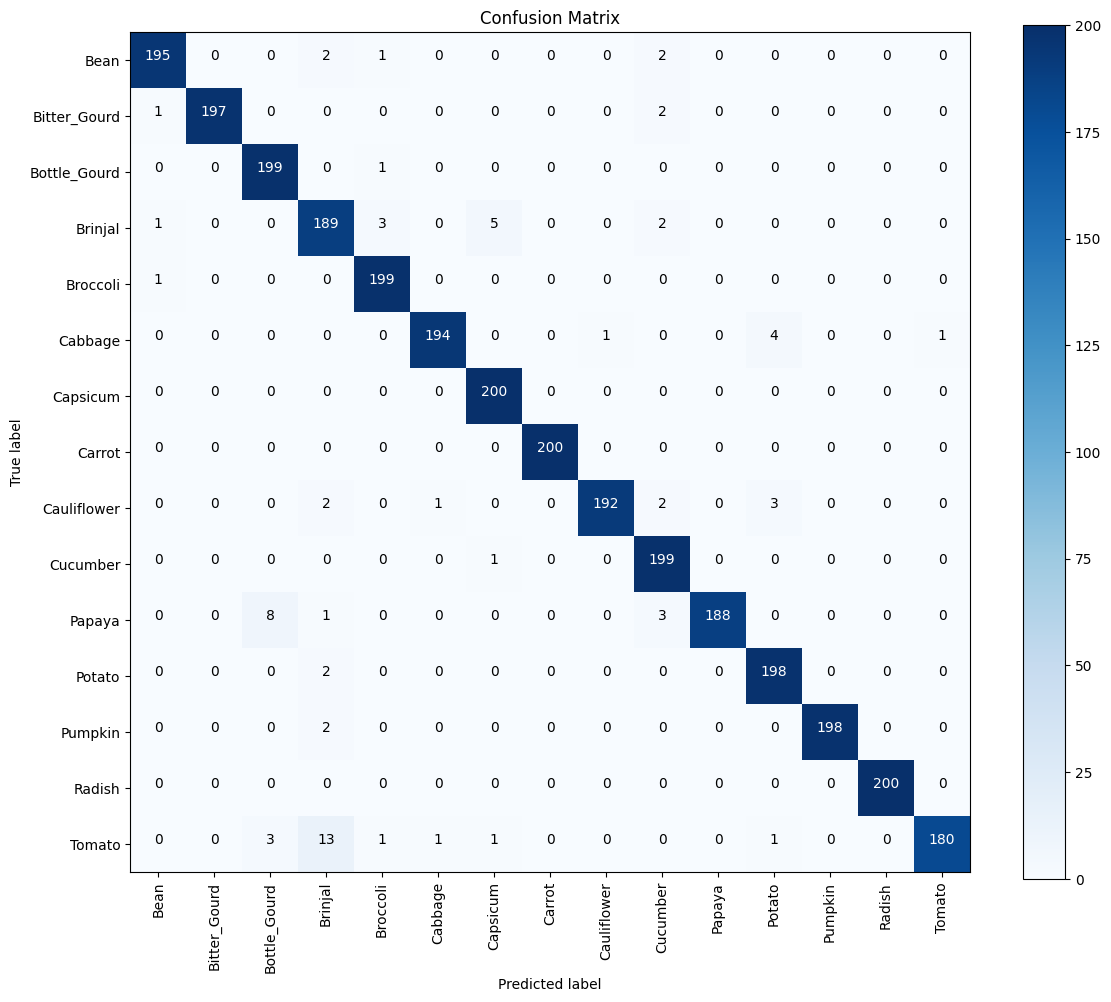

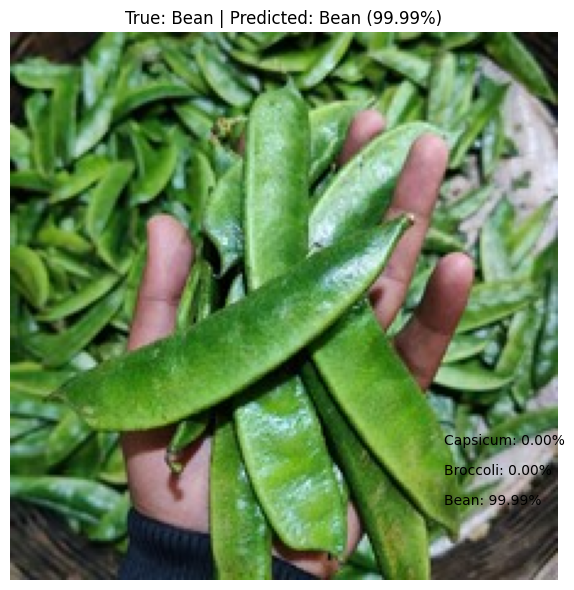

In [5]:
classifier = run_vegetable_classifier(
    data_dir='dataset', 
    num_epochs=5,                  
    batch_size=16                  
)

Using device: cuda
Model loaded from best_vegetable_model.pth
Predicted: tomato with 99.91% confidence
Top 3 predictions:
  tomato: 99.91%
  broccoli: 0.09%
  radish: 0.00%


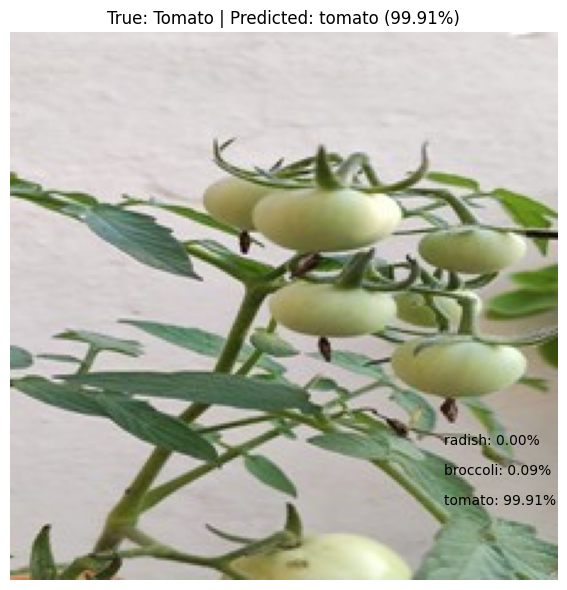

In [8]:
# Make prediction on a single image
model = VegetableClassifier(num_classes=15)  # First create the model
model.load_model('best_vegetable_model.pth')  # Then load the weights
test_image = 'dataset/test/Tomato/1010.jpg'
predicted_class, confidence, top3 = model.predict(test_image)
print(f"Predicted: {predicted_class} with {confidence:.2%} confidence")
print("Top 3 predictions:")
for veg, conf in top3:
    print(f"  {veg}: {conf:.2%}")
# Visualize the prediction
visualize_prediction(test_image, model)

Using device: cuda
Model loaded from best_vegetable_model.pth


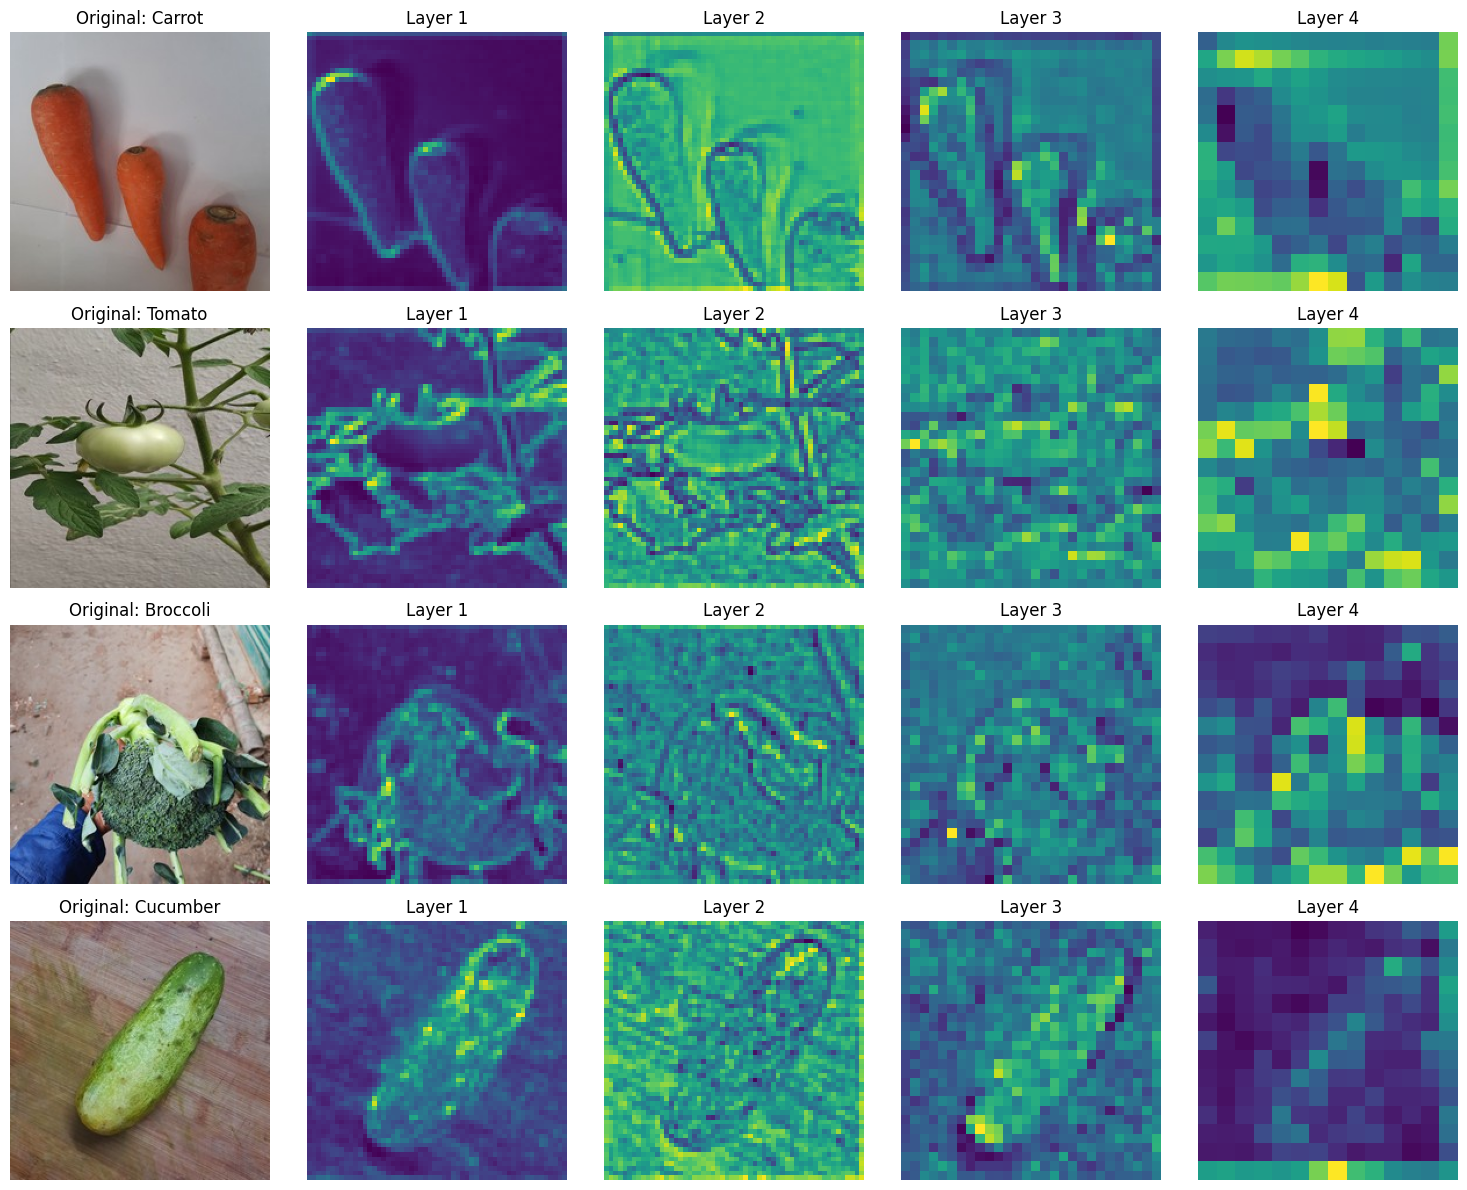

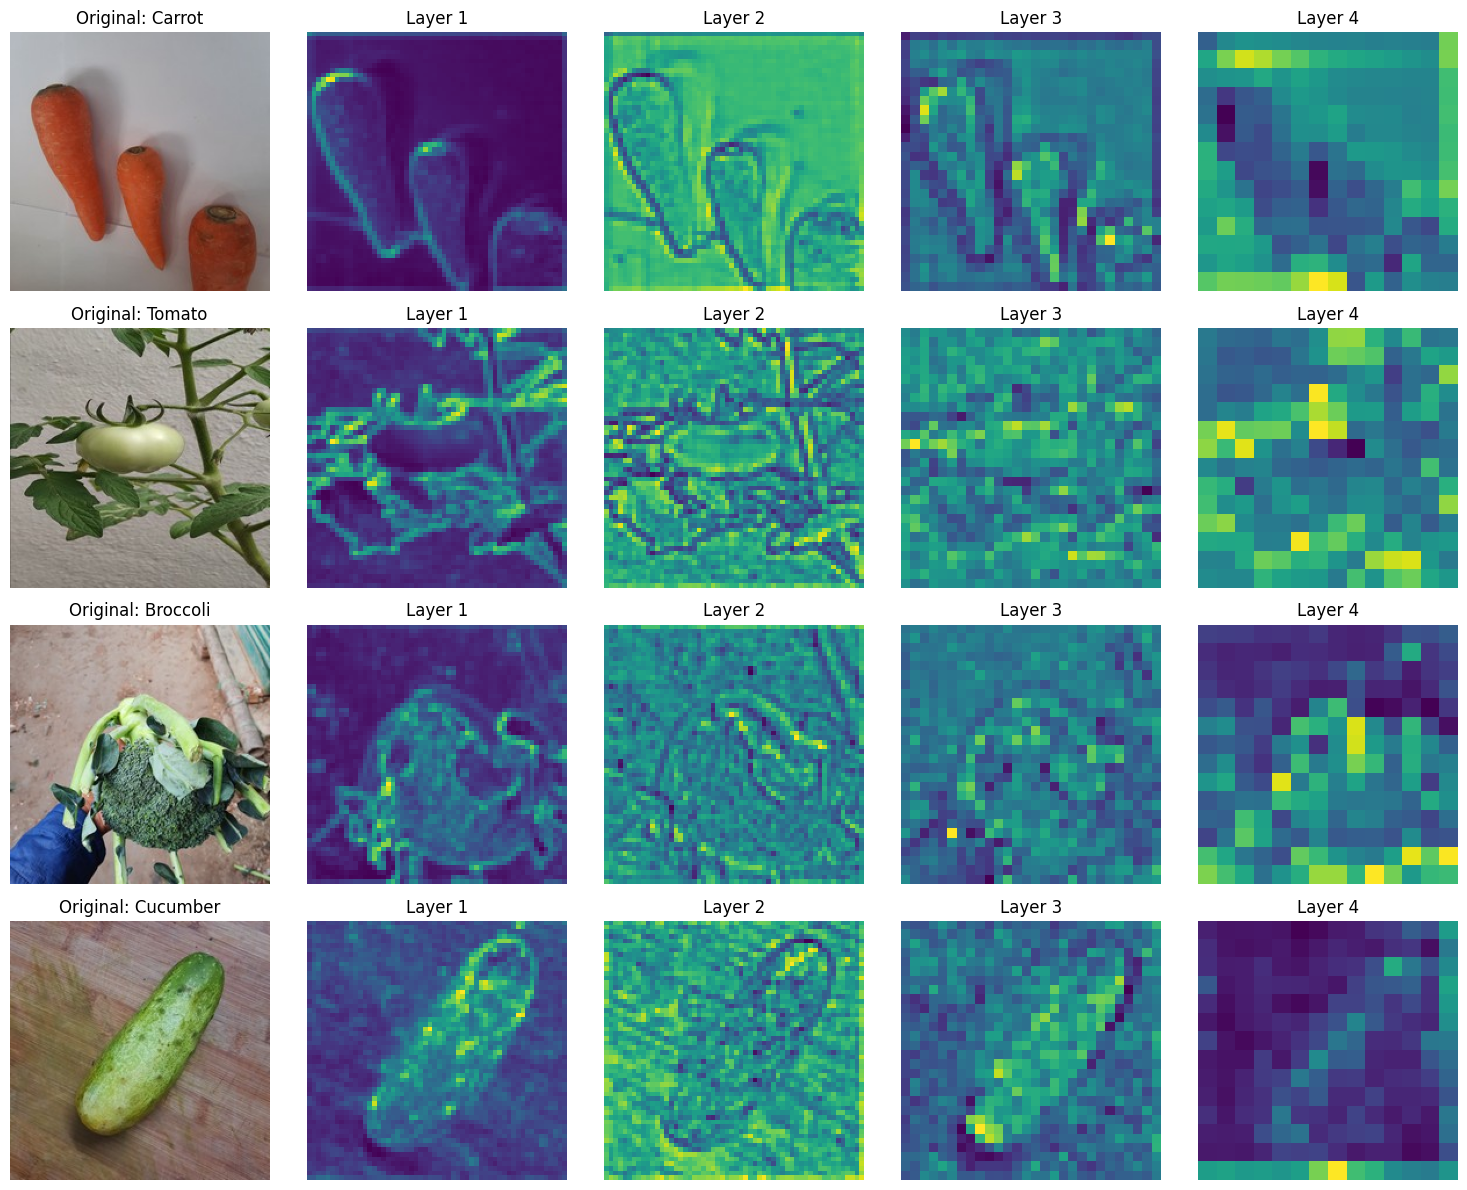

In [14]:

# Load your model (replace with your actual model loading code)
model = VegetableClassifier(num_classes=15)
model.load_model('best_vegetable_model.pth')
model = model.model  # Get the actual PyTorch model

# Define a dictionary to store the activation maps
activation = {}

# Define a hook function
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Register hooks
model.layer1[0].conv1.register_forward_hook(get_activation('layer1.0.conv1'))
model.layer2[0].conv1.register_forward_hook(get_activation('layer2.0.conv1'))
model.layer3[0].conv1.register_forward_hook(get_activation('layer3.0.conv1'))
model.layer4[0].conv1.register_forward_hook(get_activation('layer4.0.conv1'))

# Define preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Define image paths - update these with your actual paths
vegetable_images = {
    'Carrot': 'dataset/test/Carrot/1012.jpg',
    'Tomato': 'dataset/test/Tomato/1012.jpg',
    'Broccoli': 'dataset/test/Broccoli/1012.jpg',
    'Cucumber': 'dataset/test/Cucumber/1012.jpg',
}

# Generate the activation maps
def generate_activation_maps_for_vegetables(vegetable_image_paths):
    layers = ['layer1.0.conv1', 'layer2.0.conv1', 'layer3.0.conv1', 'layer4.0.conv1']
    
    fig, axes = plt.subplots(len(vegetable_image_paths), len(layers)+1, figsize=(15, 3*len(vegetable_image_paths)))
    
    for i, (vegetable_name, image_path) in enumerate(vegetable_image_paths.items()):
        # Display original image
        img = Image.open(image_path).convert('RGB')
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Original: {vegetable_name}')
        axes[i, 0].axis('off')
        
        # Process the image
        input_tensor = preprocess(img)
        input_batch = input_tensor.unsqueeze(0)

        input_batch = input_batch.to(next(model.parameters()).device)
        
        # Run model
        with torch.no_grad():
            model(input_batch)
        
        # Generate activation maps for different layers
        for j, layer in enumerate(layers):
            # Get activation for this layer
            act = activation[layer][0]
            
            # Choose a representative filter
            filter_means = act.mean(dim=(1, 2))
            best_filter = filter_means.argmax().item()
            
            # Display the activation map
            axes[i, j+1].imshow(act[best_filter].cpu(), cmap='viridis')
            axes[i, j+1].set_title(f'Layer {j+1}')
            axes[i, j+1].axis('off')
    
    plt.tight_layout()
    plt.savefig('activation_maps.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

# Run the visualization
generate_activation_maps_for_vegetables(vegetable_images)